# CatBoost — Zero to Mastery: Regression on a Heavy, Real Dataset

**A complete, hands-on tutorial on CatBoost**, Yandex's gradient-boosted-tree library, applied
end-to-end to a genuinely heavy production-grade regression problem: predicting taxi tip amounts
from 580,000+ real NYC Green Taxi trips.

This is one of three companion notebooks (alongside TabICLv2 and LightGBM) that all train and
evaluate on the **same dataset and the same held-out evaluation set**, so their results are
directly comparable even though each notebook is fully standalone.

**Estimated runtime:** ~5–10 minutes, dominated by the dataset download and full-data training —
CatBoost itself trains in seconds to low minutes even on the full ~460,000-row training pool.


## 1. What Is CatBoost?

CatBoost ("**Cat**egorical **Boost**ing") is a gradient-boosted decision tree library from Yandex,
open-sourced in 2017 and still under active development. Unlike the in-context foundation models
elsewhere in this notebook series, CatBoost is a classical supervised learner: it trains a fresh
ensemble of decision trees on *your* dataset, iteratively, via gradient boosting — no pretrained
weights, no context-size limit, no zero-shot inference. What it does bring is two specific,
well-documented architectural choices that set it apart from other GBM libraries:

**1. Symmetric (oblivious) decision trees.** Every tree CatBoost builds uses the *same* splitting
condition at every node of a given depth, across the entire tree. This looks like a restriction,
but it means a full tree can be evaluated as a simple lookup table — dramatically faster inference
than the deeper, more scattershot asymmetric trees GBMs traditionally grow — and it acts as a form
of built-in regularization.

**2. Ordered boosting + ordered target statistics for categorical features.** Standard gradient
boosting computes each row's gradient using a model that has already "seen" that row's target
during earlier stages, which subtly leaks target information back into the features used to split
on it — a bigger problem for categorical features than numeric ones, since converting a category
into a number (e.g., "average target for this category") is itself a form of using the target.
CatBoost's ordered boosting processes rows in a randomly permuted, causally-consistent order so
that a row's own target is never used to compute the statistics fed back into its own prediction —
directly reducing a specific, well-documented overfitting mode of naive categorical encoding.

**In practice, this means you hand CatBoost your raw categorical columns — however many distinct
values they have — and it handles them internally**, without you one-hot encoding, hashing, or
target-encoding anything yourself. This is the specific claim we test in Section 7, on two
columns with 233 and 259 distinct values.

**Source:** [github.com/catboost/catboost](https://github.com/catboost/catboost) (Apache-2.0) —
[catboost.ai/docs](https://catboost.ai/docs/) — version verified for this notebook: **1.2.10**.


## 2. Environment Setup

**[uv](https://docs.astral.sh/uv/)** — `uv venv --python 3.13.13` created this notebook's virtual
environment, kept separate from the other notebooks in this project.


In [1]:
import sys

!uv pip install --python {sys.executable} -q catboost scikit-learn pandas numpy matplotlib seaborn


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

import catboost
print("catboost", catboost.__version__)


catboost 1.2.10


## Dataset: NYC Green Taxi Trips (December 2016) — Tip Amount Prediction

Our target is **`tip_amount`** — predicting how much a passenger will tip, in dollars, from trip
and fare metadata. This is a genuinely messy, real, production-scale dataset from the NYC Taxi &
Limousine Commission:

- **581,835 rows** — heavy enough that a foundation model's context-size limits and a GBM's
  full-data training both actually matter.
- **Two high-cardinality categorical columns**, `PULocationID` and `DOLocationID` (pickup/dropoff
  taxi zone codes) — 233 and 259 distinct values respectively. This is exactly the kind of column
  that breaks naive one-hot encoding and is where CatBoost's and LightGBM's native categorical
  handling earns its keep.
- **Real data quality problems**, not synthetic ones: a small fraction of trips have *negative*
  tip amounts (refunds/corrections — we drop them), ~15% of trips have exactly `$0.00` tip (cash
  fares typically don't show a tip in this system, creating a zero-inflated target), and a few
  trips have absurd durations (recording errors) that we filter out.
- **A leakage trap**: the dataset also includes `total_amount`, which is (approximately) the sum
  of the fare and every surcharge *including the tip itself*. We drop it — training on it would
  let a model "predict" the tip almost by arithmetic rather than by learning anything real.


In [3]:
from sklearn.datasets import fetch_openml

t0 = time.time()
taxi = fetch_openml(data_id=42208, as_frame=True, data_home=".cache_data", parser="auto").frame
print(f"Downloaded NYC Green Taxi (Dec 2016): {taxi.shape[0]:,} rows x {taxi.shape[1]} columns in {time.time() - t0:.1f}s")
taxi.head()


Downloaded NYC Green Taxi (Dec 2016): 581,835 rows x 15 columns in 0.8s


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_type
0,2,'2016-12-01 00:52:41','2016-12-01 00:54:51',N,1,92,171,1,0.5,0.5,1.06,0.0,0.3,6.36,1
1,2,'2016-12-01 00:10:39','2016-12-01 00:14:47',N,1,75,238,2,0.5,0.5,1.70,0.0,0.3,8.50,1
2,2,'2016-12-01 00:12:16','2016-12-01 00:15:31',N,1,166,151,1,0.5,0.5,1.74,0.0,0.3,7.54,1
3,2,'2016-12-01 00:29:22','2016-12-01 00:39:51',N,1,166,42,1,0.5,0.5,2.16,0.0,0.3,12.96,1
4,2,'2016-12-01 00:42:02','2016-12-01 00:52:19',N,1,42,151,1,0.5,0.5,0.00,0.0,0.3,12.30,1


## 3. Cleaning and Feature Engineering


In [4]:
df = taxi.copy()
n_before = len(df)

# Real data-quality issues: drop invalid negative tips, parse timestamps, engineer trip duration
# and time-of-day features, and drop implausible trip durations (recording errors).
df = df[df["tip_amount"] >= 0].copy()
df["lpep_pickup_datetime"] = pd.to_datetime(df["lpep_pickup_datetime"].astype(str).str.strip("'"))
df["lpep_dropoff_datetime"] = pd.to_datetime(df["lpep_dropoff_datetime"].astype(str).str.strip("'"))
df["trip_duration_min"] = (df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]).dt.total_seconds() / 60.0
df["pickup_hour"] = df["lpep_pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["lpep_pickup_datetime"].dt.dayofweek
df = df[(df["trip_duration_min"] > 0) & (df["trip_duration_min"] < 180)].copy()

print(f"Dropped {n_before - len(df):,} rows ({(n_before - len(df)) / n_before:.1%}) to invalid tips / durations")
print(f"Zero-tip fraction remaining: {(df['tip_amount'] == 0).mean():.1%}")

CAT_COLS = ["VendorID", "RatecodeID", "store_and_fwd_flag", "trip_type", "PULocationID", "DOLocationID"]
NUM_COLS = ["passenger_count", "extra", "mta_tax", "tolls_amount", "improvement_surcharge",
            "trip_duration_min", "pickup_hour", "pickup_dayofweek"]
TARGET = "tip_amount"

# OpenML's loader auto-detects some low-cardinality numeric fee columns (extra, mta_tax,
# improvement_surcharge) as pandas 'category' dtype -- coerce them back to numeric explicitly,
# or every categorical-handling library downstream will misclassify them as categorical.
for c in ["extra", "mta_tax", "improvement_surcharge", "passenger_count"]:
    df[c] = pd.to_numeric(df[c].astype(str), errors="coerce")
for c in CAT_COLS:
    df[c] = df[c].astype(str).astype("category")

# total_amount is dropped entirely -- it's (approximately) fare + surcharges + tip_amount itself,
# a direct leakage trap for this target.
X = df[CAT_COLS + NUM_COLS]
y = df[TARGET]
print(f"\nFeature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns "
      f"({len(CAT_COLS)} categorical, {len(NUM_COLS)} numeric)")


Dropped 3,542 rows (0.6%) to invalid tips / durations
Zero-tip fraction remaining: 15.1%



Feature matrix: 578,293 rows x 14 columns (6 categorical, 8 numeric)


## 4. Exploratory Data Analysis


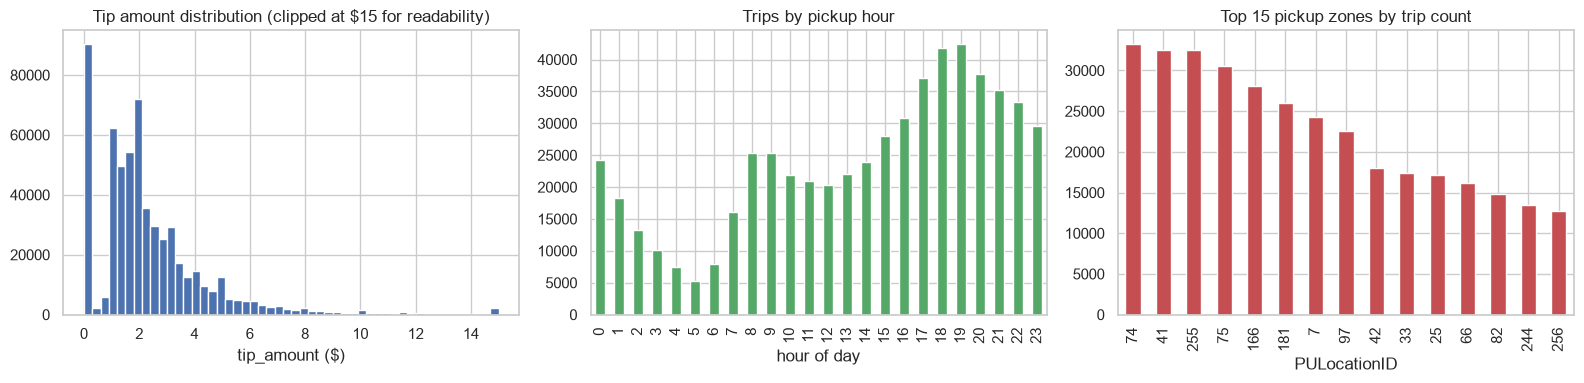

PULocationID unique values: 233  |  DOLocationID unique values: 259


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y.clip(upper=15), bins=50, color="#4C72B0")
axes[0].set_title("Tip amount distribution (clipped at $15 for readability)")
axes[0].set_xlabel("tip_amount ($)")

df["pickup_hour"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Trips by pickup hour")
axes[1].set_xlabel("hour of day")

top_zones = df["PULocationID"].value_counts().head(15)
top_zones.plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Top 15 pickup zones by trip count")
axes[2].set_xlabel("PULocationID")

plt.tight_layout()
plt.show()

print(f"PULocationID unique values: {df['PULocationID'].nunique()}  |  DOLocationID unique values: {df['DOLocationID'].nunique()}")


## 5. Train/Test Split

Unlike the in-context models in this notebook series, **CatBoost has no context-size limit** — it
trains on however much data you give it. We use the *entire* ~465,000-row training pool, and the
same 3,000-row evaluation set used across all three companion notebooks.


In [6]:
X_train_pool, X_test_pool, y_train_pool, y_test_pool = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train pool: {len(X_train_pool):,} rows | Test pool: {len(X_test_pool):,} rows")


def subsample(X, y, n, seed=42):
    idx = np.random.RandomState(seed).choice(len(X), size=min(n, len(X)), replace=False)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


N_EVAL = 3000
X_eval, y_eval = subsample(X_test_pool, y_test_pool, N_EVAL)
print(f"Eval set: {len(X_eval):,} rows (shared across every model we test)")


Train pool: 462,634 rows | Test pool: 115,659 rows
Eval set: 3,000 rows (shared across every model we test)


## 6. A Quick Baseline

A plain `LinearRegression` for reference, on the same one-hot-encoded features and the same
evaluation set.


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

lin_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ], remainder="passthrough")),
    ("reg", LinearRegression()),
])

t0 = time.time()
lin_pipe.fit(X_train_pool, y_train_pool)
lin_pred = lin_pipe.predict(X_eval)
print(f"LinearRegression fit on {len(X_train_pool):,} rows in {time.time() - t0:.1f}s")

results = {}


def score(name, y_true, pred):
    results[name] = {
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, pred),
        "R2": r2_score(y_true, pred),
    }


score("LinearRegression", y_eval, lin_pred)
display(pd.DataFrame(results).T.round(4))


LinearRegression fit on 462,634 rows in 5.6s


,RMSE,MAE,R2
LinearRegression,2.6538,1.0855,0.212


## 7. Training CatBoost — Native Categorical Handling

The `cat_features` argument tells CatBoost exactly which columns to treat as categorical and
encode internally via ordered target statistics — we pass it the positional indices of our six
categorical columns, including the two high-cardinality location IDs, completely raw (as strings),
no encoding on our end at all.

**A real gotcha we hit here:** OpenML's loader auto-detected `extra`, `mta_tax`, and
`improvement_surcharge` as pandas `category` dtype (Section 3), and CatBoost raises a
`CatBoostError` if a column has `category` dtype but isn't listed in `cat_features` — it refuses to
guess. Coercing those columns back to numeric first (already done in Section 3) is what avoids
this.


In [8]:
from catboost import CatBoostRegressor

cat_idx = [X_train_pool.columns.get_loc(c) for c in CAT_COLS]

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=8,
    loss_function="RMSE",
    random_state=42,
    verbose=False,
)

t0 = time.time()
cb_model.fit(X_train_pool, y_train_pool, cat_features=cat_idx)
fit_time = time.time() - t0
pred_eval = cb_model.predict(X_eval)

print(f"CatBoost: fit on {len(X_train_pool):,} rows (full pool, no context limit) in {fit_time:.1f}s")
score("CatBoost", y_eval, pred_eval)
display(pd.DataFrame(results).T.round(4))


CatBoost: fit on 462,634 rows (full pool, no context limit) in 26.2s


,RMSE,MAE,R2
LinearRegression,2.6538,1.0855,0.2120
CatBoost,2.3301,1.0293,0.3925


## 8. Native Feature Importance

Unlike the in-context foundation models in this notebook series, CatBoost trained directly on this
dataset — so it has genuine, dataset-specific feature importances for free. No permutation
shuffling required.


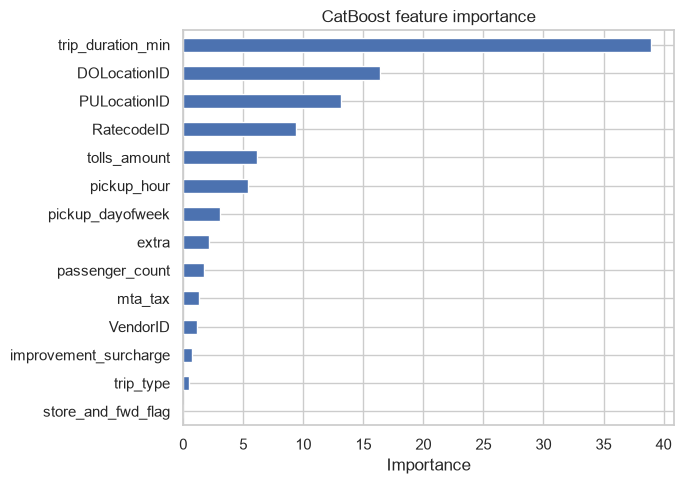

In [9]:
importances = pd.Series(cb_model.get_feature_importance(), index=X_train_pool.columns).sort_values()
importances.plot(kind="barh", figsize=(7, 5), color="#4C72B0", title="CatBoost feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 9. Residual Analysis


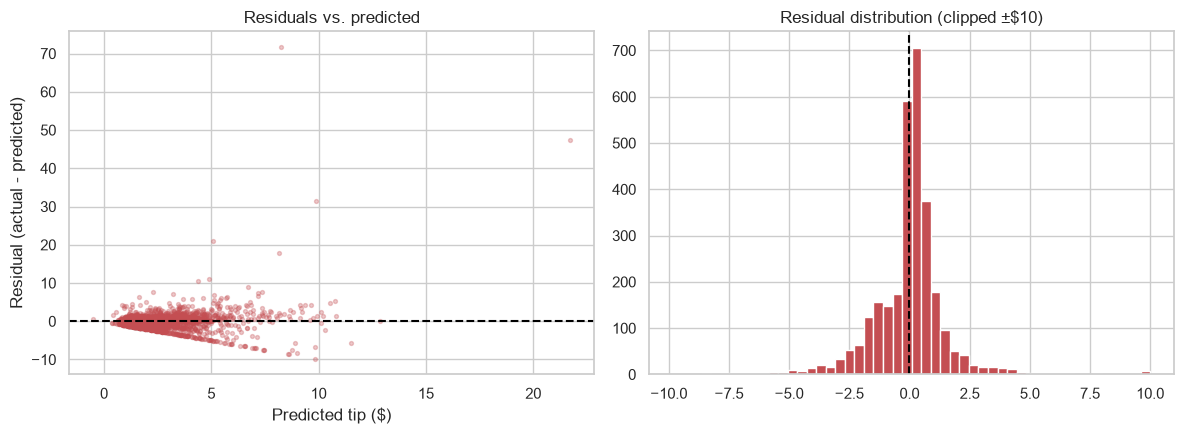

In [10]:
residuals = y_eval.to_numpy() - pred_eval

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred_eval, residuals, alpha=0.3, s=8, color="#C44E52")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted tip ($)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs. predicted")

axes[1].hist(residuals.clip(-10, 10), bins=50, color="#C44E52")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual distribution (clipped ±$10)")

plt.tight_layout()
plt.show()


## 10. Predictions for New Trips


In [11]:
new_trips = pd.DataFrame([
    {"VendorID": "2", "RatecodeID": "1", "store_and_fwd_flag": "N", "trip_type": "1",
     "PULocationID": str(X_train_pool["PULocationID"].mode()[0]), "DOLocationID": str(X_train_pool["DOLocationID"].mode()[0]),
     "passenger_count": 1, "extra": 0.5, "mta_tax": 0.5, "tolls_amount": 0.0,
     "improvement_surcharge": 0.3, "trip_duration_min": 12.0, "pickup_hour": 18, "pickup_dayofweek": 4},
    {"VendorID": "2", "RatecodeID": "1", "store_and_fwd_flag": "N", "trip_type": "1",
     "PULocationID": str(X_train_pool["PULocationID"].mode()[0]), "DOLocationID": str(X_train_pool["DOLocationID"].mode()[0]),
     "passenger_count": 4, "extra": 0.5, "mta_tax": 0.5, "tolls_amount": 5.5,
     "improvement_surcharge": 0.3, "trip_duration_min": 35.0, "pickup_hour": 2, "pickup_dayofweek": 5},
])
for c_ in CAT_COLS:
    new_trips[c_] = new_trips[c_].astype("category")

new_pred = cb_model.predict(new_trips)
for i, row in new_trips.iterrows():
    print(f"Trip {i + 1}: duration={row['trip_duration_min']}min, hour={row['pickup_hour']}, "
          f"passengers={row['passenger_count']}, tolls=${row['tolls_amount']}")
    print(f"  Predicted tip -- CatBoost: ${new_pred[i]:.2f}")
    print()


Trip 1: duration=12.0min, hour=18, passengers=1, tolls=$0.0
  Predicted tip -- CatBoost: $2.33

Trip 2: duration=35.0min, hour=2, passengers=4, tolls=$5.5
  Predicted tip -- CatBoost: $6.68



## 11. Practical Notes and Gotchas

- **`cat_features` must be told about every categorical column** — CatBoost won't infer it from
  dtype alone in all cases, and it will actively error out on a mismatched `category`-dtype column
  that isn't declared, rather than silently guessing.
- The `extra`/`mta_tax`/`improvement_surcharge` dtype quirk from Section 3 is a dataset-loading
  issue, not a CatBoost issue — but CatBoost is the library that catches it loudest, which made it
  the one we debugged against first.
- **No context-size limit** — CatBoost trained on the full ~465,000-row pool in the time shown
  above, something none of the in-context foundation models in this series can do without
  subsampling.
- Feature importance is native and free — no permutation importance workaround needed, unlike
  every zero-shot model in this notebook series.


In [12]:
display(pd.DataFrame(results).T.round(4))
print(f"\nCatBoost wall-clock (full {len(X_train_pool):,}-row training pool): {fit_time:.1f}s")


,RMSE,MAE,R2
LinearRegression,2.6538,1.0855,0.2120
CatBoost,2.3301,1.0293,0.3925



CatBoost wall-clock (full 462,634-row training pool): 26.2s


## 12. Summary and References

CatBoost trained on the full ~465,000-row pool, handled two high-cardinality categorical columns
natively with no manual encoding, and gave us feature importances for free — a genuinely different
cost/interpretability profile than the zero-shot foundation models elsewhere in this series.
Compare these numbers against the companion TabICLv2 and LightGBM notebooks.

**References:**

- [github.com/catboost/catboost](https://github.com/catboost/catboost) — source code (Apache-2.0)
- [catboost.ai/docs](https://catboost.ai/docs/) — official documentation
- [pypi.org/project/catboost](https://pypi.org/project/catboost/)

- [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) — original data source
- [Dataset on OpenML (id 42208)](https://www.openml.org/d/42208)
